# Análise de jogos da Steam

Exploração dos dados processados pelo pipeline, a partir da camada `marts`.

**Perguntas de negócio:**
1. Quais jogos têm o melhor custo-benefício?
2. Como os jogos se distribuem entre as faixas de preço?
3. Quais estúdios têm mais jogos bem avaliados?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
pasta_marts = Path("../data/marts")
arquivo = sorted(pasta_marts.glob("mart_jogos_*.parquet"))[-1]

df = pd.read_parquet(arquivo)
print(f"Carregado: {arquivo.name}")
print(f"Formato: {df.shape}")
df.head()

Carregado: mart_jogos_2026-07-30.parquet
Formato: (5000, 18)


,appid,name,developer,publisher,positive,negative,owners,price,initialprice,discount,ccu,owners_min,owners_max,owners_estimate,total_avaliacoes,taxa_aprovacao,faixa_preco,custo_beneficio
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0.00,0.00,0,1013936,100000000,200000000,150000000,8815087,0.866932,Grátis,NaN
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0.00,0.00,0,124262,100000000,200000000,150000000,994979,0.671424,Grátis,NaN
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0.00,0.00,0,314682,100000000,200000000,150000000,2557944,0.594406,Grátis,NaN
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",29.99,29.99,0,18028,50000000,100000000,75000000,380709,0.941049,Médio,0.031379
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0.00,0.00,0,43819,50000000,100000000,75000000,1161472,0.899087,Grátis,NaN


## 1. Distribuição de jogos por faixa de preço

Quantos jogos existem em cada faixa? Isso mostra o perfil de preços do catálogo.

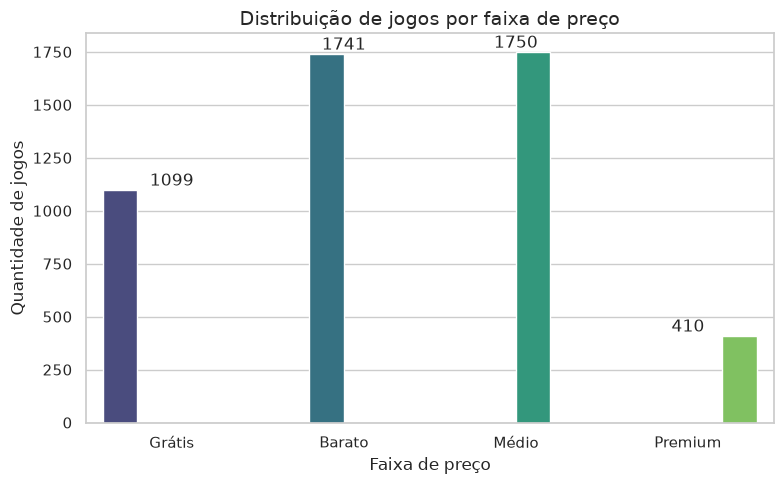

In [3]:
contagem = df["faixa_preco"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=contagem.index, y=contagem.values, ax=ax, palette="viridis", hue=contagem.index, legend=False)

ax.set_title("Distribuição de jogos por faixa de preço", fontsize=14)
ax.set_xlabel("Faixa de preço")
ax.set_ylabel("Quantidade de jogos")

for i, valor in enumerate(contagem.values):
    ax.text(i, valor + 20, str(valor), ha="center")

plt.tight_layout()
plt.show()

## 2. Top 10 jogos por custo-benefício

Quais jogos entregam mais aprovação por dólar? Considera apenas jogos pagos
(grátis foram excluídos, pois custo-benefício não se aplica).
Filtramos jogos com pelo menos 500 avaliações, para evitar títulos obscuros
com poucas avaliações inflando o ranking.

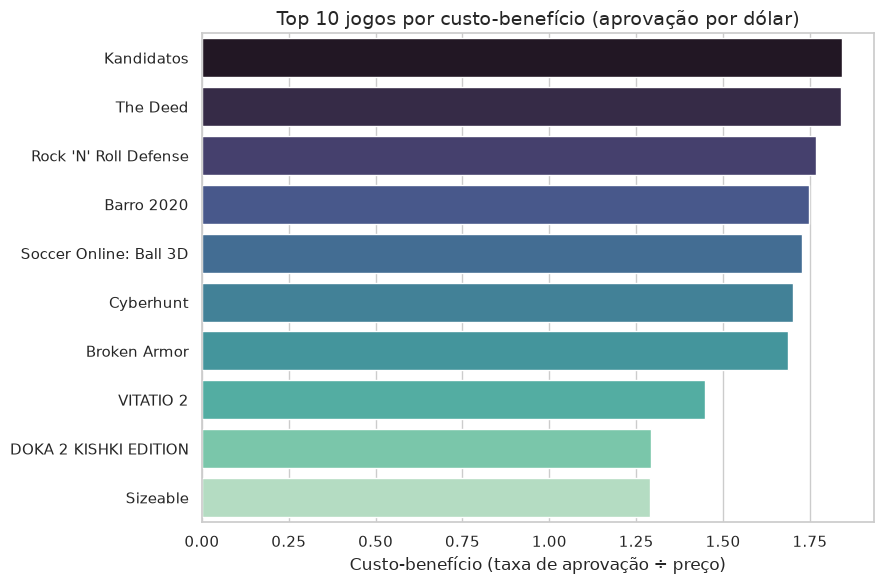

In [4]:
com_relevancia = df[df["total_avaliacoes"] >= 500]

top10 = com_relevancia.nlargest(10, "custo_beneficio")

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top10, x="custo_beneficio", y="name", ax=ax, palette="mako", hue="name", legend=False)

ax.set_title("Top 10 jogos por custo-benefício (aprovação por dólar)", fontsize=14)
ax.set_xlabel("Custo-benefício (taxa de aprovação ÷ preço)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Estúdios com mais jogos bem avaliados

Quais desenvolvedores têm mais jogos com alta aprovação (≥ 80%) e
relevância (≥ 500 avaliações)? Mede consistência de qualidade por estúdio.

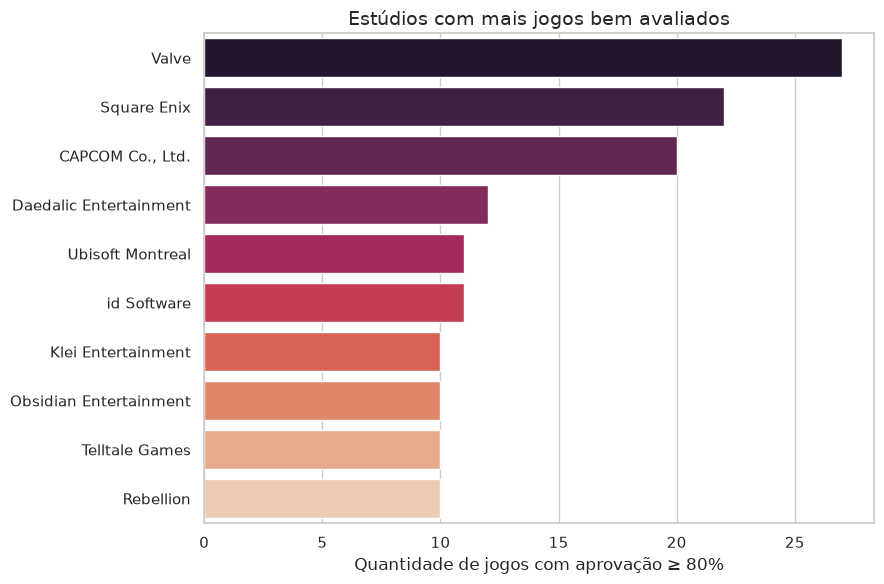

In [5]:
bem_avaliados = df[(df["taxa_aprovacao"] >= 0.80) & (df["total_avaliacoes"] >= 500)]

top_estudios = (
    bem_avaliados["developer"]
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_estudios.values, y=top_estudios.index, ax=ax, palette="rocket", hue=top_estudios.index, legend=False)

ax.set_title("Estúdios com mais jogos bem avaliados", fontsize=14)
ax.set_xlabel("Quantidade de jogos com aprovação ≥ 80%")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## Conclusões

- **Distribuição de preços:** o catálogo se concentra nas faixas Barato e Médio
  (~1750 jogos cada); jogos Premium (> US$ 30) são minoria (410).

- **Custo-benefício:** a métrica (aprovação ÷ preço) é enviesada a favor de
  jogos muito baratos — títulos de ~US$ 0,49 dominam mesmo com filtro de
  relevância. Útil para "máximo de aprovação por dólar", mas não para
  "melhores jogos". Toda métrica embute uma definição.

- **Estúdios:** filtrando por aprovação ≥ 80% e ≥ 500 avaliações, emergem nomes
  consagrados (Valve, Capcom, id Software) e indies consistentes (Klei,
  Obsidian) — validando que a métrica de qualidade-com-relevância é robusta.

---

*Análise gerada a partir da camada `marts` do pipeline `steam-pipeline`.*